### Import des librairies

In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ─── PyTorch (remplace TensorFlow / Keras) ───────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
# ─────────────────────────────────────────────────────────────────────────────

# ─── Optuna (remplace keras_tuner) ───────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# ─────────────────────────────────────────────────────────────────────────────

# Imports locaux (inchangés)
from import_dataset import load_dataset
from explore_data import downsample_data, plot_xy_grid, plot_3d, txt_to_df
from Edit_distance import edit_distance
from functions_nb import load_domain4_dataset, standardize_group, count_gestures



85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1
Erreur sur 3001.txt: name 'txt_to_df' is not defined
Erreur sur 3002.txt: name 'txt_to_df' is not defined
Erreur sur 3003.txt: name 'txt_to_df' is not defined
Erreur sur 3004.txt: name 'txt_to_df' is not defined
Erreur sur 3005.txt: name 'txt_to_df' is not defined
Erreur sur 3006.txt: name 'txt_to_df' is not defined
Erreur sur 3007.txt: name 'txt_to_df' is not defined
Erreur sur 3008.txt: name 'txt_to_df' is not defined
Erreur sur 3009.txt: name 'txt_to_df' is not defined
Erreur sur 3010.txt: name 'txt_to_df' is not

ImportError: cannot import name 'plot_3d' from 'explore_data' (c:\Users\nmohy\OneDrive\Documents\0_I²\1_MA\M3_LSM\Q2\Artificial Intelligence\projet\Code\Gesture-Recognition-Project\explore_data.py)

Vérification du setup de la Carte Graphique

In [2]:
print("Version PyTorch :", torch.__version__)
print("CUDA compilé :", torch.version.cuda)
print("CUDA dispo :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Version PyTorch : 2.2.2+cu121
CUDA compilé : 12.1
CUDA dispo : True
GPU : NVIDIA GeForce RTX 4060 Laptop GPU


Pour être d'avoir un entrainement reproductible 

In [ ]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Force PyTorch à être déterministe
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)

set_global_seed(42)

# Import data & preprocessing

In [3]:
BASE_DIR = os.getcwd()

DATA_DIR_DOMAIN1 = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")
DATA_DIR_DOMAIN4 = os.path.join(BASE_DIR,"Dataset", "Domain4_csv")

print("Chargement du dataset de Domain1...")
dataset_domain1 = pd.concat(load_dataset(DATA_DIR_DOMAIN1), ignore_index=True)


df_domain1 = dataset_domain1.copy()

print("Domain 1 chargé.")
print(f"{len(dataset_domain1)} fichiers chargés .") 
print(f"Dimension du dataset : {dataset_domain1.shape}")
print(df_domain1.head())

print("\nChargement du dataset de Domain4...")


domain4_files = os.listdir(DATA_DIR_DOMAIN4)

# Si le dossier Domain 4 contient des .txt, on utilise le chargeur spécial.
# Sinon, on garde ton load_dataset classique.
if any(file.endswith(".txt") for file in domain4_files):
    dataset_domain4 = pd.concat(load_domain4_dataset(DATA_DIR_DOMAIN4), ignore_index=True)
else:
    dataset_domain4 = pd.concat(load_dataset(DATA_DIR_DOMAIN4), ignore_index=True)

df_domain4 = dataset_domain4.copy()

print("Domain 4 chargé.")
print(f"{len(dataset_domain4)} lignes chargées.")
print(f"Dimension du dataset : {dataset_domain4.shape}")
print(dataset_domain4.head())

print("\n=== Vérification Domain 4 ===")
print("Colonnes :", dataset_domain4.columns.tolist())
print("Nombre de sujets :", dataset_domain4["subject_id"].nunique())
print("Classes :", sorted(dataset_domain4["digit"].unique()))
print("Nombre total de gestes :", dataset_domain4.groupby(["subject_id", "digit", "repetition"]).ngroups)
print(dataset_domain4.groupby(["subject_id", "digit"])["repetition"].nunique().head(20))

Chargement du dataset de Domain1...
Domain 1 chargé.
85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1

Chargement du dataset de Domain4...
Domain 4 chargé.
139988 lignes chargées.
Dimension du dataset : (139988, 9)
   subject_id  digit  repetition         x         y         z      t  \
0           1      1           1 -0.036230 -0.000405  0.272364   19.0   
1           1      1           1 -0.036027 -0.000367  0.272408   51.0   
2           1      1           1 -0.036877  0.001244  0.272449   83.0   
3           1      1           1 -0.036252  0.001105  0.272484 

In [4]:
df_domain1_std = df_domain1.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 

print("Standardisation terminéé")
df_domain1_std.head()

Standardisation terminéé


,x,y,z,t,subject_id,digit,repetition,x_std,y_std,z_std
0,0.042075,0.036799,0.258380,6.0,1,0,1,0.568231,0.840300,0.660208
1,0.041904,0.037187,0.258505,37.0,1,0,1,0.564132,0.849559,0.667987
2,0.041739,0.037219,0.258619,67.0,1,0,1,0.560178,0.850323,0.675083
3,0.041446,0.037573,0.258731,101.0,1,0,1,0.553155,0.858770,0.682053
4,0.041303,0.037331,0.258830,132.0,1,0,1,0.549728,0.852995,0.688215


In [5]:
df_domain1_downsampled = (
    df_domain1.groupby(['subject_id', 'digit', 'repetition'], group_keys=False)
    .apply(downsample_data)
    .reset_index(drop=True)
)

df_domain1_downsampled_std = df_domain1_downsampled.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 


print("Downsampling + standardisation terminés.")
print("Nombre de gestes :", count_gestures(df_domain1_downsampled))
print(df_domain1_downsampled.head())



Downsampling + standardisation terminés.
Nombre de gestes : 1000
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041739  0.037219  0.258619   67.0           1      0           1
2  0.041303  0.037331  0.258830  132.0           1      0           1
3  0.039765  0.038245  0.259025  214.0           1      0           1
4  0.037329  0.038885  0.259251  277.0           1      0           1


In [6]:
df_domain4_std = df_domain4.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 

print("Standardisation terminéé")
df_domain4_std.head()

Standardisation terminéé


,subject_id,digit,repetition,x,y,z,t,domain_id,filename,x_std,y_std,z_std
0,1,1,1,-0.036230,-0.000405,0.272364,19.0,4,3001.txt,-1.103553,0.802268,-0.486407
1,1,1,1,-0.036027,-0.000367,0.272408,51.0,4,3001.txt,-1.099213,0.803333,-0.485419
2,1,1,1,-0.036877,0.001244,0.272449,83.0,4,3001.txt,-1.117386,0.848486,-0.484499
3,1,1,1,-0.036252,0.001105,0.272484,115.0,4,3001.txt,-1.104023,0.844591,-0.483713
4,1,1,1,-0.035431,0.000880,0.272513,146.0,4,3001.txt,-1.086471,0.838284,-0.483062


In [7]:
df_domain4_downsampled = (
    df_domain4.groupby(['subject_id', 'digit', 'repetition'], group_keys=False)
    .apply(downsample_data)
    .reset_index(drop=True)
)

df_domain4_downsampled_std = df_domain4_downsampled.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 

print("Downsampling + standardisation terminés.")
print("Nombre de gestes :", count_gestures(df_domain4_downsampled))
print(df_domain4_downsampled.head())



Downsampling + standardisation terminés.
Nombre de gestes : 1003
   subject_id  digit  repetition         x         y         z      t  \
0           1      1           1 -0.036230 -0.000405  0.272364   19.0   
1           1      1           1 -0.036877  0.001244  0.272449   83.0   
2           1      1           1 -0.035431  0.000880  0.272513  146.0   
3           1      1           1 -0.034735 -0.000143  0.272561  211.0   
4           1      1           1 -0.034517 -0.002117  0.272595  290.0   

   domain_id  filename  
0          4  3001.txt  
1          4  3001.txt  
2          4  3001.txt  
3          4  3001.txt  
4          4  3001.txt  


In [8]:
def prepare_sequences_for_deep_learning(df):
    X_sequences = []
    y_labels = []
    subjects = []
    repetitions = []

    for (subject_id, digit, repetition), group in df.groupby(['subject_id', 'digit', 'repetition']):
        group = group.sort_values('t')
        sequence = group[['x_std', 'y_std', 'z_std']].values.astype('float32')
        X_sequences.append(sequence)
        y_labels.append(digit)
        subjects.append(subject_id)
        repetitions.append(repetition)

    return X_sequences, np.array(y_labels), np.array(subjects), np.array(repetitions)


DATASETS = {
    name: prepare_sequences_for_deep_learning(df)
    for name, df in {
        'domain1'            : df_domain1_std,
        'domain1_downsampled': df_domain1_downsampled_std,
        'domain4'            : df_domain4_std,
        'domain4_downsampled': df_domain4_downsampled_std,
    }.items()
}

def print_X_seq_y_labels(X_sequences, y_labels):
    print("Nombre de séquences :", len(X_sequences))
    print("Shape d'une séquence :", X_sequences[0].shape)
    print("Classes :", sorted(np.unique(y_labels)))

def select_dataset(name):
    """
    Sélectionne un dataset par son nom.

    Args:
        name : str — clé parmi DATASETS

    Returns:
        X_sequences, y_labels, subjects, repetitions
    """
    if name not in DATASETS:
        raise ValueError(
            f"Dataset '{name}' inconnu.\n"
            f"Choix disponibles : {list(DATASETS.keys())}"
        )

    X, y, subjects, repetitions = DATASETS[name]
    print(f"=== {name.upper()} ===")
    print_X_seq_y_labels(X, y)
    return X, y, subjects, repetitions

# **Ici sélectionner le nom du DATASET que l'on veut étudier**

In [82]:
DATASET_NAME = 'domain1_downsampled'   # ← seule ligne à modifier

X_sequences, y_labels, subjects, repetitions = select_dataset(DATASET_NAME)

print("Nombre de séquences :", len(X_sequences))
print("Shape d'une séquence :", X_sequences[0].shape)
print("Classes :", sorted(np.unique(y_labels)))

=== DOMAIN1_DOWNSAMPLED ===
Nombre de séquences : 1000
Shape d'une séquence : (64, 3)
Classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Nombre de séquences : 1000
Shape d'une séquence : (64, 3)
Classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [83]:
# ─── Padding avec PyTorch (remplace keras pad_sequences) ─────────────────────
# pad_sequence attend des tenseurs triés par longueur décroissante (optionnel ici)
# On garde également les longueurs réelles pour le masquage via PackedSequence

max_len = max(len(seq) for seq in X_sequences)
num_classes = 10

# Conversion en tenseurs PyTorch
seq_tensors = [torch.tensor(seq, dtype=torch.float32) for seq in X_sequences]
seq_lengths = torch.tensor([len(seq) for seq in X_sequences], dtype=torch.long)

# pad_sequence retourne (max_len, batch, features) → on transpose en (batch, max_len, features)
X_padded_tensor = pad_sequence(seq_tensors, batch_first=True, padding_value=0.0)

# Version numpy pour compatibilité sklearn (train_test_split, etc.)
X_padded = X_padded_tensor.numpy()
lengths_np = seq_lengths.numpy()

print("Longueur maximale :", max_len)
print("Shape X_padded :", X_padded.shape)

Longueur maximale : 121
Shape X_padded : (1000, 121, 3)


In [84]:
# ─── Encodage des labels ──────────────────────────────────────────────────────
# PyTorch CrossEntropyLoss attend des indices entiers (pas de one-hot)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)  # entiers 0..9

print("Classes originales :", label_encoder.classes_)
print("Shape y_encoded :", y_encoded.shape)

Classes originales : [0 1 2 3 4 5 6 7 8 9]
Shape y_encoded : (1000,)


In [85]:
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    X_padded,
    y_encoded,
    lengths_np,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 121, 3)
X_test  : (200, 121, 3)
y_train : (800,)
y_test  : (200,)


# Dataset PyTorch & utilitaires d'entraînement

In [86]:
# ─── Dataset custom ───────────────────────────────────────────────────────────
class GestureDataset(Dataset):
    """Encapsule (X, y, lengths) pour un DataLoader PyTorch."""
    def __init__(self, X, y, lengths):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


# ─── EarlyStopping (remplace keras.callbacks.EarlyStopping) ──────────────────
class EarlyStopping:
    """Stoppe l'entraînement si val_loss ne s'améliore pas pendant `patience` époques."""
    def __init__(self, patience=5, min_delta = 1e-4, restore_best_weights=True):
        self.patience           = patience
        self.min_delta            = min_delta # pour gagner du temps dans l'entrainement et éviter de chercher la précision absolue (seuil minimum d'amélioration de val_loss)
        self.restore_best_weights = restore_best_weights
        self.best_loss          = float('inf')
        self.counter            = 0
        self.best_state         = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            if self.restore_best_weights:
                import copy
                self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# ─── Boucle d'entraînement générique ─────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=100, patience=10, lr=1e-3, device=None):
    """
    Remplace model.fit() de Keras.
    Retourne un dictionnaire 'history' analogue à history.history de Keras.
    """
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.CrossEntropyLoss()
    es         = EarlyStopping(patience=patience, min_delta=1e-4, restore_best_weights=True)
    history    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    model.to(device)

    for epoch in range(epochs):
        # ── Entraînement ──
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch, len_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch, len_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(y_batch)
            train_correct += (logits.argmax(1) == y_batch).sum().item()
            train_total   += len(y_batch)

        # ── Validation ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch, len_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits  = model(X_batch, len_batch)
                loss    = criterion(logits, y_batch)
                val_loss    += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
                val_total   += len(y_batch)

        t_loss = train_loss / train_total
        t_acc  = train_correct / train_total
        v_loss = val_loss / val_total
        v_acc  = val_correct / val_total

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Époque {epoch+1:3d} | train_loss={t_loss:.4f} acc={t_acc:.4f} "
                  f"| val_loss={v_loss:.4f} acc={v_acc:.4f}")

        if es.step(v_loss, model):
            print(f"Early stopping à l'époque {epoch+1}")
            break

    es.restore(model)
    return history


def evaluate_model(model, loader, device=None):
    """Remplace model.evaluate() de Keras. Retourne (loss, accuracy)."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch, len_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch, len_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total

In [69]:
# ─── Modèle RNN générique (LSTM ou GRU) ──────────────────────────────────────
# Remplace keras.Sequential avec Masking + LSTM/GRU + Dropout + Dense
# Le masquage est géré via pack_padded_sequence (équivalent du Masking de Keras)

class RNNModel(nn.Module):
    """
    Architecture équivalente au modèle Keras :
        Masking  →  LSTM/GRU(64)  →  Dropout(0.3)  →  Dense(32, relu)  →  Dense(num_classes, softmax)

    Le masquage est réalisé par pack_padded_sequence qui ignore les pas de temps
    correspondant au padding (équivalent exact de la couche Masking de Keras).
    """
    def __init__(self, input_size, hidden_size, num_classes, rnn_type='LSTM',
                 num_layers=1, dropout=0.3, recurrent_dropout=0.0):
        super().__init__()
        self.rnn_type = rnn_type

        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU

        # recurrent_dropout → dropout entre couches cachées (nécessite num_layers > 1 dans PyTorch)
        rnn_dropout = recurrent_dropout if num_layers > 1 else 0.0

        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, num_classes)
        # Note : pas de Softmax ici — nn.CrossEntropyLoss l'intègre déjà

    def forward(self, x, lengths):
        # ── Masquage via PackedSequence (équivalent Masking de Keras) ──────────
        # Les longueurs doivent être sur CPU pour pack_padded_sequence
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, hidden = self.rnn(packed)
        # ─────────────────────────────────────────────────────────────────────

        # Récupération du dernier état caché (équivalent return_sequences=False)
        if self.rnn_type == 'LSTM':
            h_n = hidden[0][-1]   # (batch, hidden_size)
        else:
            h_n = hidden[-1]       # (batch, hidden_size)

        out = self.dropout(h_n)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [87]:
# ─── Préparation des DataLoaders ──────────────────────────────────────────────
BATCH_SIZE = 32

train_dataset = GestureDataset(X_train, y_train, len_train)
test_dataset  = GestureDataset(X_test,  y_test,  len_test)

# Découpage train / val (80/20) pour l'entraînement — même ratio que Keras validation_split=0.2
n_val       = int(0.2 * len(train_dataset))
n_train_eff = len(train_dataset) - n_val
train_sub, val_sub = torch.utils.data.random_split(
    train_dataset, [n_train_eff, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_sub,  batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_sub,    batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

INPUT_SIZE   = X_train.shape[2]   # 3 (x_std, y_std, z_std)
NUM_CLASSES  = len(label_encoder.classes_)

In [71]:
def get_predictions(model, loader, device=device):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch, len_batch in loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch, len_batch)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

# Model implementation Test préliminaire

In [20]:
# ─── Modèle LSTM ──────────────────────────────────────────────────────────────
model_lstm = RNNModel(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_classes=NUM_CLASSES,
    rnn_type='LSTM',
    dropout=0.3
)

print(model_lstm)
print(f"Paramètres entraînables : {sum(p.numel() for p in model_lstm.parameters() if p.requires_grad):,}")

RNNModel(
  (rnn): LSTM(3, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
Paramètres entraînables : 20,074


In [21]:
# ─── Entraînement LSTM ────────────────────────────────────────────────────────
history_lstm = train_model(
    model_lstm, train_loader, val_loader,
    epochs=100, patience=10, lr=1e-3
)

Époque  10 | train_loss=0.5403 acc=0.7953 | val_loss=0.6585 acc=0.7438
Époque  20 | train_loss=0.1717 acc=0.9641 | val_loss=0.2690 acc=0.9313
Époque  30 | train_loss=0.0448 acc=0.9938 | val_loss=0.1300 acc=0.9625
Early stopping à l'époque 38


In [22]:
loss_lstm, acc_lstm = evaluate_model(model_lstm, test_loader)
print(f"LSTM test accuracy: {acc_lstm:.4f} ({acc_lstm*100:.2f}%)")

LSTM test accuracy: 0.9900 (99.00%)


In [23]:
# ─── Modèle GRU ───────────────────────────────────────────────────────────────
model_gru = RNNModel(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_classes=NUM_CLASSES,
    rnn_type='GRU',
    dropout=0.3
)

print(model_gru)
print(f"Paramètres entraînables : {sum(p.numel() for p in model_gru.parameters() if p.requires_grad):,}")

RNNModel(
  (rnn): GRU(3, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
Paramètres entraînables : 15,658


In [24]:
history_gru = train_model(
    model_gru, train_loader, val_loader,
    epochs=100, patience=10, lr=1e-3
)

Époque  10 | train_loss=0.7160 acc=0.7047 | val_loss=0.6992 acc=0.7000
Époque  20 | train_loss=0.3639 acc=0.8656 | val_loss=0.4279 acc=0.8688
Époque  30 | train_loss=0.1183 acc=0.9750 | val_loss=0.2662 acc=0.9437
Époque  40 | train_loss=0.0420 acc=0.9922 | val_loss=0.1672 acc=0.9563
Époque  50 | train_loss=0.0311 acc=0.9906 | val_loss=0.1495 acc=0.9688
Early stopping à l'époque 56


In [25]:
loss_gru, acc_gru = evaluate_model(model_gru, test_loader)
print(f"GRU test accuracy: {acc_gru:.4f} ({acc_gru*100:.2f}%)")

GRU test accuracy: 0.9750 (97.50%)


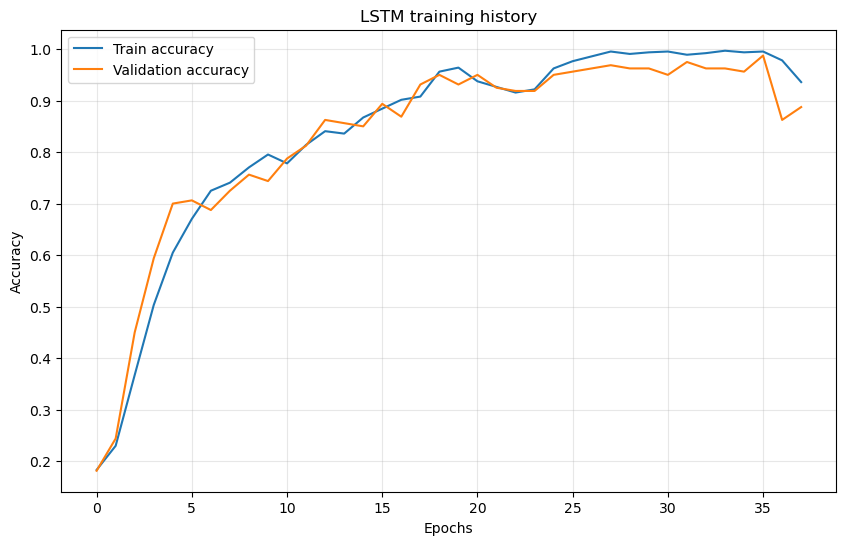

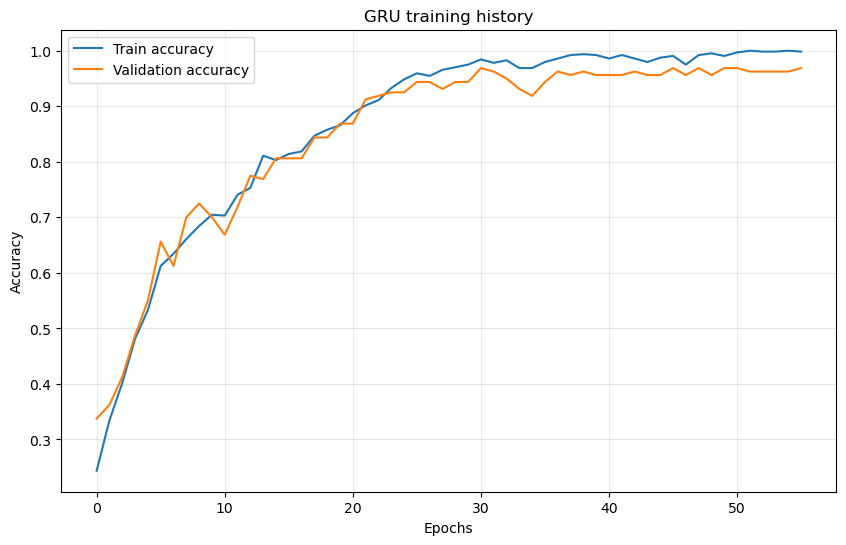

In [26]:
# ─── Courbes d'apprentissage ──────────────────────────────────────────────────
# Identique à Keras, history est maintenant un dict Python standard

plt.figure(figsize=(10, 6))
plt.plot(history_lstm['train_acc'], label='Train accuracy')
plt.plot(history_lstm['val_acc'],   label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM training history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_gru['train_acc'], label='Train accuracy')
plt.plot(history_gru['val_acc'],   label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('GRU training history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

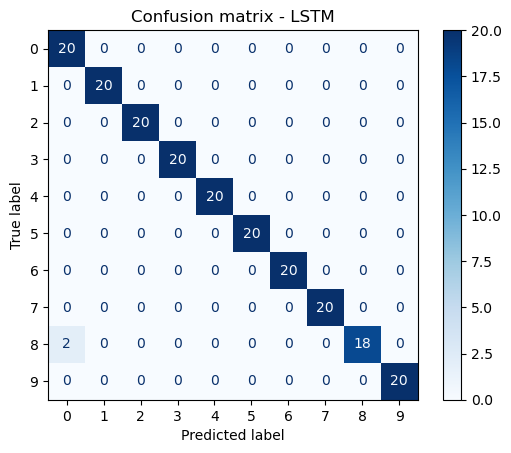

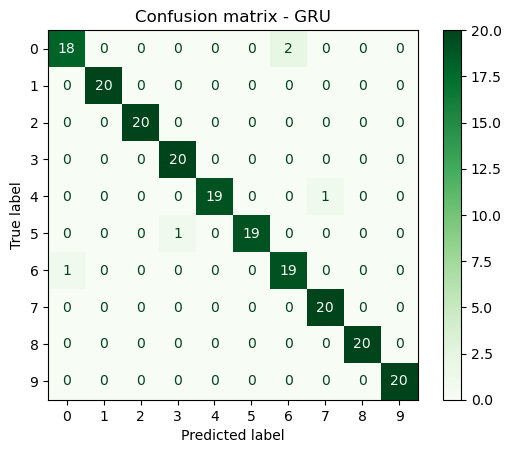

In [28]:
# ─── Matrices de confusion ────────────────────────────────────────────────────
def get_predictions(model, loader, device=None):
    """Remplace model.predict() de Keras."""
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch, len_batch in loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch, len_batch)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

y_true, y_pred_lstm = get_predictions(model_lstm, test_loader)

cm_lstm = confusion_matrix(y_true, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix - LSTM")
plt.show()

_, y_pred_gru = get_predictions(model_gru, test_loader)
cm_gru = confusion_matrix(y_true, y_pred_gru)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion matrix - GRU")
plt.show()

# Double cross-validation pour évaluer les hyperparamètres

Pour la gestion de l'inner loop sur les subjects

In [ ]:
def build_optuna_objective_independent(X_tr, y_tr, len_tr, subjects_tr,
                                        rnn_type='LSTM', device=None):
    def objective(trial):

        # ✅ Seed déterministe par trial → même split à chaque run
        trial_seed = 42 + trial.number
        np.random.seed(trial_seed)
        torch.manual_seed(trial_seed)

        # ── Split par sujet reproductible ─────────────────────────────────────
        unique_inner_subjects = np.unique(subjects_tr)
        n_val_subj  = max(1, int(len(unique_inner_subjects) * 0.2))
        val_subjects = np.random.choice(unique_inner_subjects,
                                        size=n_val_subj, replace=False)

        inner_train_mask = ~np.isin(subjects_tr, val_subjects)
        inner_val_mask   =  np.isin(subjects_tr, val_subjects)

        X_inner_tr,  y_inner_tr,  len_inner_tr  = (X_tr[inner_train_mask],
                                                    y_tr[inner_train_mask],
                                                    len_tr[inner_train_mask])
        X_inner_val, y_inner_val, len_inner_val  = (X_tr[inner_val_mask],
                                                    y_tr[inner_val_mask],
                                                    len_tr[inner_val_mask])

        num_layers  = trial.suggest_int('num_layers', 1, 2) # limiter à 2 et pas aller à 3
        units       = trial.suggest_categorical('units', [16, 32,64]) # limiter taille couches pour éviter réseaux trop complexe par rapport au problème.
        dropout     = trial.suggest_float('dropout', 0.2, 0.5, step=0.1) # imposer un dropout minimum pour éviter overfitting
        lr          = trial.suggest_categorical('learning_rate', [1e-2, 1e-3, 1e-4]) # contrôle vitesse d'entrainement

        # C'est très efficace contre l'overfitting !
        weight_decay = trial.suggest_categorical('weight_decay', [1e-4, 1e-5, 0.0])

        model = RNNModel(
            input_size=INPUT_SIZE,
            hidden_size=units,
            num_classes=NUM_CLASSES,
            rnn_type=rnn_type,
            num_layers=num_layers,
            dropout=dropout,
        )

        # ✅ DataLoader reproductible via generator seedé
        g = torch.Generator()
        g.manual_seed(trial_seed)

        tr_ld  = DataLoader(GestureDataset(X_inner_tr,  y_inner_tr,  len_inner_tr),
                            batch_size=BATCH_SIZE, shuffle=True,
                            generator=g)                              # ← ajout
        val_ld = DataLoader(GestureDataset(X_inner_val, y_inner_val, len_inner_val),
                            batch_size=BATCH_SIZE)

        history = train_model(model, tr_ld, val_ld,
                              epochs=30, patience=5, lr=lr,
                              weight_decay=weight_decay, device=device)
        return max(history['val_acc'])

    return objective

In [ ]:
def build_optuna_objective_user_dependent(X_tr, y_tr, len_tr, repetitions_tr,
                                           rnn_type='LSTM', device=device):
    """
    Inner loop LORO : retire une répétition pour la validation.
    Remplace le split par sujet du user-independent.
    """
    def objective(trial):
        # ── Split par répétition (LORO inner) ─────────────────────────────────
        unique_inner_reps = np.unique(repetitions_tr)
        # On choisit aléatoirement ~20% des répétitions pour la validation
        n_val_reps = max(1, int(len(unique_inner_reps) * 0.2))
        val_reps   = np.random.choice(unique_inner_reps,
                                       size=n_val_reps, replace=False)

        inner_train_mask = ~np.isin(repetitions_tr, val_reps)
        inner_val_mask   =  np.isin(repetitions_tr, val_reps)

        X_inner_tr,  y_inner_tr,  len_inner_tr  = (X_tr[inner_train_mask],
                                                    y_tr[inner_train_mask],
                                                    len_tr[inner_train_mask])
        X_inner_val, y_inner_val, len_inner_val  = (X_tr[inner_val_mask],
                                                    y_tr[inner_val_mask],
                                                    len_tr[inner_val_mask])
        # ──────────────────────────────────────────────────────────────────────

        num_layers  = trial.suggest_int('num_layers', 1, 2) # limiter à 2 et pas aller à 3
        units       = trial.suggest_categorical('units', [16, 32,64]) # limiter taille couches pour éviter réseaux trop complexe par rapport au problème.
        dropout     = trial.suggest_float('dropout', 0.2, 0.5, step=0.1) # imposer un dropout minimum pour éviter overfitting
        lr          = trial.suggest_categorical('learning_rate', [1e-2, 1e-3, 1e-4]) # contrôle vitesse d'entrainement

        # C'est très efficace contre l'overfitting !
        weight_decay = trial.suggest_categorical('weight_decay', [1e-4, 1e-5, 0.0])

        model = RNNModel(
            input_size=INPUT_SIZE,
            hidden_size=units,
            num_classes=NUM_CLASSES,
            rnn_type=rnn_type,
            num_layers=num_layers,
            dropout=dropout,
        )

        tr_ld  = DataLoader(GestureDataset(X_inner_tr,  y_inner_tr,  len_inner_tr),
                            batch_size=BATCH_SIZE, shuffle=True)
        val_ld = DataLoader(GestureDataset(X_inner_val, y_inner_val, len_inner_val),
                            batch_size=BATCH_SIZE)

        history = train_model(model, tr_ld, val_ld,
                              epochs=30, patience=5, lr=lr,
                              weight_decay=weight_decay, device=device)
        return max(history['val_acc'])

    return objective

## User-Independent

In [ ]:
def nested_cv_user_independent_numpy(X_padded, y_encoded, lengths_np, subjects, rnn_type='LSTM',dataset_name='domain1',device=None):
    """
    Cross-validation user-indépendant avec optimisation Optuna (remplace KerasTuner).
    Chaque sujet est utilisé une fois comme ensemble de test (Leave-One-Subject-Out).
    """
    print(f"Analyse User-Independent sur {dataset_name}")
    csv_results  = []
    unique_users = np.unique(subjects)

    for test_user in unique_users: # gestion outer loop( Leave-One-Out pour le Test)
        print(f"\n{'='*50}\nOuter Fold - Test sur le Sujet {test_user}\n{'='*50}")

        # ── Masques NumPy ──────────────────────────────────────────────────────
        test_mask  = (subjects == test_user)
        train_mask = ~test_mask

        X_tr, y_tr, len_tr = X_padded[train_mask], y_encoded[train_mask], lengths_np[train_mask]
        X_te, y_te, len_te = X_padded[test_mask],  y_encoded[test_mask],  lengths_np[test_mask]

        # ── Recherche Optuna (remplace tuner.search de KerasTuner) ────────────
        
        print("--- Début de la recherche d'hyperparamètres (Optuna) ---")
        study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(
            build_optuna_objective_independent(X_tr, y_tr, len_tr, subjects_tr=subjects[train_mask], rnn_type=rnn_type,device=device),
            n_trials= 15   
        )

        best_params = study.best_params
        print(f"Meilleurs hyperparamètres : {best_params}")

        hp_layers     = best_params['num_layers']
        hp_units      = best_params['units']
        hp_dropout    = best_params['dropout']
        hp_rec_dropout = best_params['recurrent_dropout']
        hp_lr         = best_params['learning_rate']

        trial = study.best_trial
        print(f"Trial n°{trial.number} — val_acc={trial.value:.4f}")

        # Affichage console — identique à ton code Keras
        print(f"\n>>> Meilleurs Hyperparamètres trouvés pour exclure le Sujet {test_user} :")
        print(f"    - Couches: {hp_layers} | Neurones: {hp_units}")
        print(f"    - Dropout: {hp_dropout:.1f} | Recurrent Dropout: {hp_rec_dropout:.1f}")
        print(f"    - Learning Rate: {hp_lr}")
        print("-" * 50)

        # ── Réentraînement avec les meilleurs hyperparamètres ─────────────────
        best_model = RNNModel(
            input_size=INPUT_SIZE,
            hidden_size=best_params['units'],
            num_classes=NUM_CLASSES,
            rnn_type=rnn_type,
            num_layers=best_params['num_layers'],
            dropout=best_params['dropout'],
            recurrent_dropout=best_params['recurrent_dropout']
        )


        # 1. Identifier les 9 sujets d'entraînement disponibles
        subjects_tr = subjects[train_mask]
        unique_inner_subjects = np.unique(subjects_tr)
        
        # Toujours le premier sujet disponible → déterministe ET varie par fold
        # car unique_inner_subjects change à chaque fold outer
        val_subject_final = unique_inner_subjects[0]
        
        final_train_mask = (subjects_tr != val_subject_final)
        final_val_mask   = (subjects_tr == val_subject_final)

        X_final_tr, y_final_tr, len_final_tr = X_tr[final_train_mask], y_tr[final_train_mask], len_tr[final_train_mask]
        X_final_vl, y_final_vl, len_final_vl = X_tr[final_val_mask],   y_tr[final_val_mask],   len_tr[final_val_mask]

        tr_ld = DataLoader(GestureDataset(X_final_tr, y_final_tr, len_final_tr), batch_size=BATCH_SIZE, shuffle=True)
        vl_ld = DataLoader(GestureDataset(X_final_vl, y_final_vl, len_final_vl), batch_size=BATCH_SIZE)

        train_model(best_model, tr_ld, vl_ld, epochs=100, patience=10,
                    lr=best_params['learning_rate'], device=device)
        

        # ── Prédictions sur l'ensemble de test ────────────────────────────────
        te_loader   = DataLoader(GestureDataset(X_te, y_te, len_te), batch_size=BATCH_SIZE)
        true_labels, predictions = get_predictions(best_model, te_loader,device)

        test_repetitions = repetitions[test_mask]
        for i in range(len(predictions)):
            csv_results.append({
                'subject_id':      test_user,
                'repetition':      test_repetitions[i],
                'true_digit':      true_labels[i],
                'predicted_digit': predictions[i],
                'is_correct':      int(true_labels[i] == predictions[i]),
                'hp_num_layers': hp_layers,
                'hp_units': hp_units,
                'hp_dropout': hp_dropout,
                'hp_recurrent_dropout': hp_rec_dropout,
                'hp_learning_rate': hp_lr
            })

        fold_acc = np.mean([r['is_correct'] for r in csv_results if r['subject_id'] == test_user])
        print(f"Accuracy sur Sujet {test_user}: {fold_acc*100:.2f}%")

    # ── Bilan final & export CSV ───────────────────────────────────────────────
    df_results   = pd.DataFrame(csv_results)
    overall_acc  = df_results['is_correct'].mean()
    print(f"\nAccuracy Globale (User-Independent): {overall_acc*100:.2f}%")

    csv_result_path = f'Resultats_statistiques/resultats_user_indep_{dataset_name}_{rnn_type}_PyTorch.csv'

    df_results.to_csv(csv_result_path, index=False)
    print(f"Résultats sauvegardés dans {csv_result_path}")

    # ---------------------------------------------------------
    # Calcul de l'accuracy par Sujet ET par Geste
    # ---------------------------------------------------------
    # 1. On groupe les données par 'subject_id' et 'true_digit'
    # 2. On calcule la moyenne de 'is_correct' (ce qui donne l'accuracy)
    df_detail = df_results.groupby(['subject_id', 'true_digit'])['is_correct'].mean().reset_index()
    
    # 3. On renomme les colonnes pour respecter exactement ce que tu as demandé
    df_detail.rename(columns={
        'subject_id': 'Subject_Id', 
        'true_digit': 'digit', 
        'is_correct': 'accuracy'
    }, inplace=True)
    
    # 4. On exporte ce nouveau tableau dans un second fichier CSV
    fichier_detail = f'Resultats_statistiques/Accuracy_par_sujet_et_geste/resultats_user_indep_{dataset_name}_{rnn_type}_PyTorch.csv'
    df_detail.to_csv(fichier_detail, index=False)
    print(f"Nouveau fichier créé : {fichier_detail} (10 lignes par sujet)")
    # ---------------------------------------------------------

    return df_results

In [90]:
rnn_type = 'GRU'   # ou 'GRU'
df_result = nested_cv_user_independent_numpy(
    X_padded, y_encoded, lengths_np, subjects, rnn_type=rnn_type, dataset_name= DATASET_NAME, device=device)

Analyse User-Independent sur domain1_downsampled

Outer Fold - Test sur le Sujet 1
--- Début de la recherche d'hyperparamètres (Optuna) ---
Époque  10 | train_loss=0.7208 acc=0.7150 | val_loss=0.6691 acc=0.7400
Époque  20 | train_loss=0.4546 acc=0.8187 | val_loss=0.4707 acc=0.8300
Époque  30 | train_loss=0.3046 acc=0.8962 | val_loss=0.3117 acc=0.8700
Époque  10 | train_loss=1.8284 acc=0.3350 | val_loss=1.7682 acc=0.3400
Époque  20 | train_loss=1.1507 acc=0.5925 | val_loss=1.1406 acc=0.5700
Époque  30 | train_loss=0.8479 acc=0.6562 | val_loss=0.9059 acc=0.7000
Époque  10 | train_loss=0.4225 acc=0.8413 | val_loss=0.4617 acc=0.8500
Époque  20 | train_loss=0.1053 acc=0.9738 | val_loss=0.1831 acc=0.9900
Époque  30 | train_loss=0.0128 acc=0.9988 | val_loss=0.1731 acc=0.9800
Époque  10 | train_loss=0.2398 acc=0.9287 | val_loss=0.2863 acc=0.9300
Époque  20 | train_loss=0.0126 acc=0.9988 | val_loss=0.1009 acc=0.9900
Early stopping à l'époque 26
Époque  10 | train_loss=0.5211 acc=0.8263 | val_lo

[W 2026-05-07 08:53:25,783] Trial 6 failed with parameters: {'num_layers': 2, 'units': 32, 'dropout': 0.0, 'recurrent_dropout': 0.0, 'learning_rate': 0.0001} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\nmohy\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\nmohy\AppData\Local\Temp\ipykernel_53776\1893346946.py", line 52, in objective
    history = train_model(model, tr_ld, val_ld,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nmohy\AppData\Local\Temp\ipykernel_53776\457279551.py", line 65, in train_model
    loss.backward()
  File "c:\Users\nmohy\anaconda3\Lib\site-packages\torch\_tensor.py", line 522, in backward
    torch.autograd.backward(
  File "c:\Users\nmohy\anaconda3\Lib\site-packages\torch\autograd\__init__.py", line 266, in backward
    Variable._execution_engine.run_backward(  # Cal

KeyboardInterrupt: 

## User-Dependent

In [ ]:
def nested_cv_user_dependent(X_padded, y_encoded, lengths_np,
                              subjects, repetitions,
                              rnn_type='LSTM', dataset_name='domain1',device=device):
    """
    Cross-validation user-dépendant avec Optuna.
    Pour chaque sujet : Leave-One-Repetition-Out en outer loop.
    Un modèle distinct est entraîné par sujet.
    """
    csv_results  = []
    unique_users = np.unique(subjects)

    # ── Boucle sur chaque sujet ───────────────────────────────────────────────
    for subject_id in unique_users:
        print(f"\n{'='*50}\nSujet {subject_id}\n{'='*50}")

        # Isolation des données du sujet courant
        subj_mask   = (subjects == subject_id)
        X_subj      = X_padded[subj_mask]
        y_subj      = y_encoded[subj_mask]
        len_subj    = lengths_np[subj_mask]
        reps_subj   = repetitions[subj_mask]

        unique_reps = np.unique(reps_subj)

        # ── Outer loop : Leave-One-Repetition-Out ────────────────────────────
        for test_rep in unique_reps:
            print(f"\n  Outer Fold — Test sur la Répétition {test_rep}")

            test_mask  = (reps_subj == test_rep)
            train_mask = ~test_mask

            X_tr,  y_tr,  len_tr  = X_subj[train_mask], y_subj[train_mask], len_subj[train_mask]
            X_te,  y_te,  len_te  = X_subj[test_mask],  y_subj[test_mask],  len_subj[test_mask]
            reps_tr = reps_subj[train_mask]

            # ── Recherche Optuna (inner loop LORO) ───────────────────────────
            print("  --- Recherche d'hyperparamètres (Optuna) ---")
            study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(
                build_optuna_objective_user_dependent(
                    X_tr, y_tr, len_tr,
                    repetitions_tr=reps_tr,   # ← répétitions au lieu de sujets
                    rnn_type=rnn_type,device=device
                ),
                n_trials=20
            )

            best_params = study.best_params
            print(f"  Meilleurs hyperparamètres : {best_params}")

            hp_layers      = best_params['num_layers']
            hp_units       = best_params['units']
            hp_dropout     = best_params['dropout']
            hp_rec_dropout = best_params['recurrent_dropout']
            hp_lr          = best_params['learning_rate']

            # ── Réentraînement sur toutes les répétitions sauf test ──────────
            best_model = RNNModel(
                input_size=INPUT_SIZE,
                hidden_size=hp_units,
                num_classes=NUM_CLASSES,
                rnn_type=rnn_type,
                num_layers=hp_layers,
                dropout=hp_dropout,
                recurrent_dropout=hp_rec_dropout
            )

            unique_inner_reps = np.unique(reps_tr)
            val_rep_final     = unique_inner_reps[0]  # 1ère répétition dispo → varie par fold

            final_train_mask = (reps_tr != val_rep_final)
            final_val_mask   = (reps_tr == val_rep_final)

            X_final_tr,  y_final_tr,  len_final_tr  = X_tr[final_train_mask], y_tr[final_train_mask], len_tr[final_train_mask]
            X_final_val, y_final_val, len_final_val = X_tr[final_val_mask],   y_tr[final_val_mask],   len_tr[final_val_mask]

            tr_ld = DataLoader(GestureDataset(X_final_tr,  y_final_tr,  len_final_tr),  batch_size=BATCH_SIZE, shuffle=True)
            vl_ld = DataLoader(GestureDataset(X_final_val, y_final_val, len_final_val), batch_size=BATCH_SIZE)

            train_model(best_model, tr_ld, vl_ld,
                        epochs=100, patience=10, lr=hp_lr,device=device)

            # ── Prédictions sur la répétition test ───────────────────────────
            te_loader = DataLoader(
                GestureDataset(X_te, y_te, len_te), batch_size=BATCH_SIZE
            )
            true_labels, predictions = get_predictions(best_model, te_loader)

            for i in range(len(predictions)):
                csv_results.append({
                    'subject_id':        subject_id,
                    'repetition':        test_rep,
                    'true_digit':        true_labels[i],
                    'predicted_digit':   predictions[i],
                    'is_correct':        int(true_labels[i] == predictions[i]),
                    'hp_num_layers':     hp_layers,
                    'hp_units':          hp_units,
                    'hp_dropout':        hp_dropout,
                    'hp_recurrent_dropout': hp_rec_dropout,
                    'hp_learning_rate':  hp_lr
                })

        # Accuracy par sujet
        subj_acc = np.mean([r['is_correct'] for r in csv_results
                            if r['subject_id'] == subject_id])
        print(f"\nAccuracy Sujet {subject_id}: {subj_acc*100:.2f}%")

    # ── Bilan final & export CSV ──────────────────────────────────────────────
    df_results  = pd.DataFrame(csv_results)
    overall_acc = df_results['is_correct'].mean()
    print(f"\nAccuracy Globale (User-Dependent): {overall_acc*100:.2f}%")

    csv_path = f'Resultats_statistiques/resultats_user_dep_{dataset_name}_PyTorch.csv'
    df_results.to_csv(csv_path, index=False)
    print(f"Résultats sauvegardés dans {csv_path}")
    return df_results

In [ ]:
rnn_type = 'LSTM'   # ou 'GRU'
df_result = nested_cv_user_dependent_numpy(
    X_padded, y_encoded, lengths_np, subjects, rnn_type=rnn_type, dataset_name= DATASET_NAME, device=device)